In [154]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scanpy as sc
from starcat import starCAT
from scipy.stats import ttest_ind, fisher_exact, ranksums, wilcoxon
import sys
from statsmodels.stats.multitest import fdrcorrection
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
import os

import requests
import openpyxl
import pandas as pd
import numpy as np
from io import BytesIO
from cnmf import cNMF
import scanpy as sc
from scipy.stats import ttest_rel
from sklearn.neighbors import NearestNeighbors
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
import joblib


sys.path.append('../../../Code')
from utils import read_dataset_log

In [155]:
from matplotlib import rcParams, font_manager
import matplotlib


rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

In [156]:
figdir = '../../../Figures/Components/Revision'

In [157]:
outdir = '../../../Data/Revision/CRC_Outcome/'

# Normalization

In [132]:
adata = sc.read('../../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.h5ad')

In [133]:
adata.obs['timepoint'] = adata.obs['Treatment'].replace({'untreated':'Pre', 'anti-PD-1':'Post', 'Anti-PD-1+celecoxib':'Post'})
adata.obs['response'] = adata.obs['response'].replace({'pCR':'Responder', 'non-pCR':'Non-responder'})
adata.obs['sample'] = adata.obs['Patient'].astype(str) + '_' + adata.obs['Type'].astype(str)  +  '_' + adata.obs['timepoint'].astype(str)

In [134]:
adata.write('../../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.h5ad')

In [5]:
adata.var.head()

,Ensemble,Gene_Symbol,feature_types
MIR1302-2HG,ENSG00000243485,MIR1302-2HG,Gene Expression
FAM138A,ENSG00000237613,FAM138A,Gene Expression
OR4F5,ENSG00000186092,OR4F5,Gene Expression
AL627309.1,ENSG00000238009,AL627309.1,Gene Expression
AL627309.3,ENSG00000239945,AL627309.3,Gene Expression


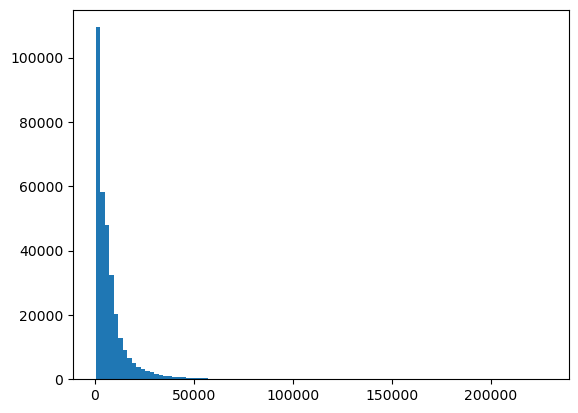

In [6]:
_ = plt.hist(np.array(adata.X.sum(axis=1)).reshape(-1), bins=100)

In [7]:
adata.shape

(324020, 33538)

In [8]:
sc.pp.filter_genes(adata, min_cells=10)

In [9]:
adata.shape

(324020, 25151)

In [10]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)

In [11]:
adata.X = adata.X.astype(np.float64)

In [12]:
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e6)

In [13]:
sc.pp.log1p(adata)

In [14]:
sc.pp.pca(adata, mask_var='highly_variable')

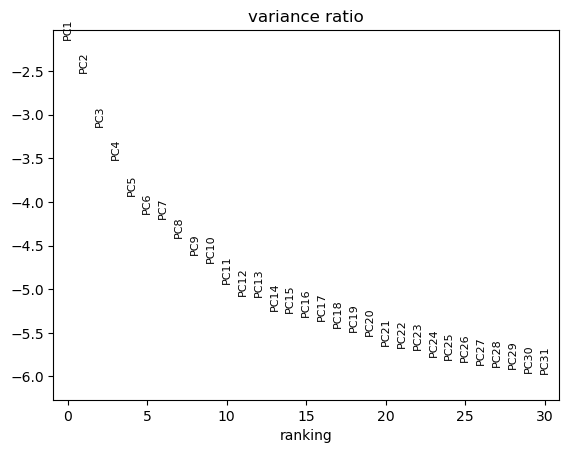

In [15]:
sc.pl.pca_variance_ratio(adata, log=True)

In [16]:
sc.external.pp.harmony_integrate(adata, key=['sample'])

2024-10-29 01:23:22,619 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-10-29 01:24:10,368 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-10-29 01:24:13,907 - harmonypy - INFO - Iteration 1 of 10
2024-10-29 01:29:09,067 - harmonypy - INFO - Iteration 2 of 10
2024-10-29 01:33:56,088 - harmonypy - INFO - Iteration 3 of 10
2024-10-29 01:38:44,121 - harmonypy - INFO - Iteration 4 of 10
2024-10-29 01:43:33,469 - harmonypy - INFO - Iteration 5 of 10
2024-10-29 01:48:20,985 - harmonypy - INFO - Converged after 5 iterations


In [17]:
adata

AnnData object with n_obs × n_vars = 324020 × 25151
    obs: 'file', 'GSM', 'MGI', 'sample', 'version', 'Patient', 'Location', 'Type', 'Treatment', 'Tumor anatomical location', 'Mismatch repair defective protein', 'Microsatellite status', 'Stage(cTMN)', 'Sex', 'Age', 'Tumor_Pre', 'Tumor_Post', 'Normal', 'response', 'n_counts'
    var: 'Ensemble', 'Gene_Symbol', 'feature_types', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'

In [18]:
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20, use_rep='X_pca_harmony')

In [ ]:
sc.tl.umap(adata)

In [ ]:
adata.write('../../../Data/Revision/CRC_Outcome/GSE205506_combined_logtpm.h5ad')

In [ ]:
sc.pl.umap(adata, color=['Patient', 'Treatment'])

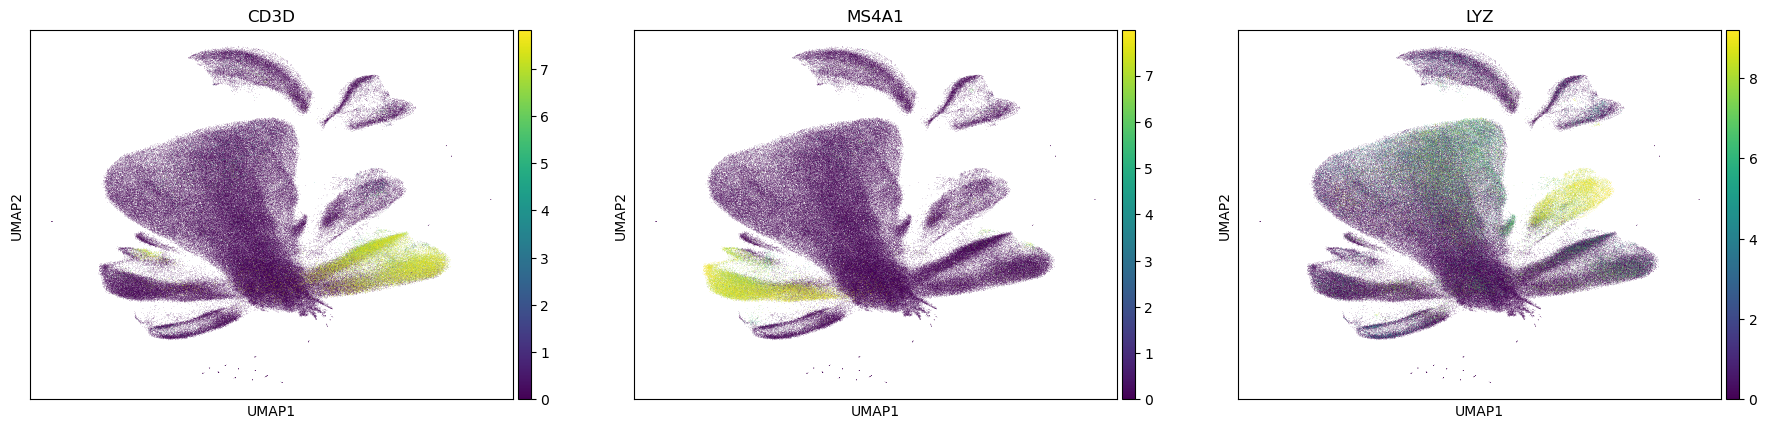

In [26]:
sc.pl.umap(adata, color=['CD3D', 'MS4A1', 'LYZ'], vmax='p99')

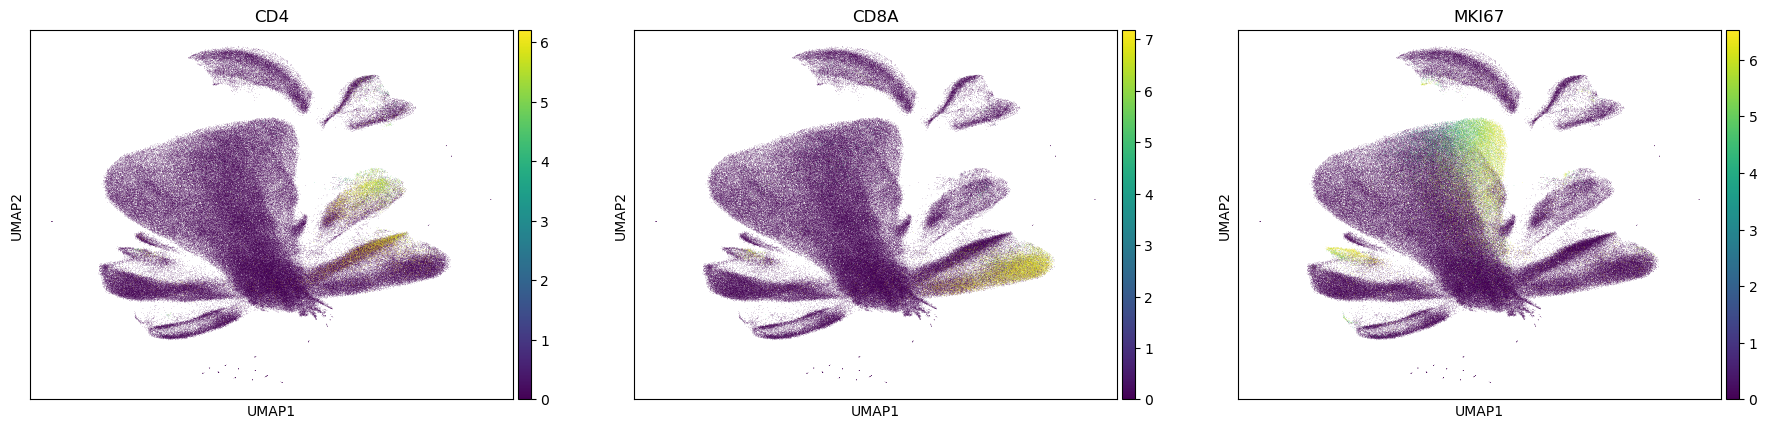

In [27]:
sc.pl.umap(adata, color=['CD4', 'CD8A', 'MKI67'], vmax='p99')

In [ ]:
sc.tl.leiden(adata, resolution=1.0)

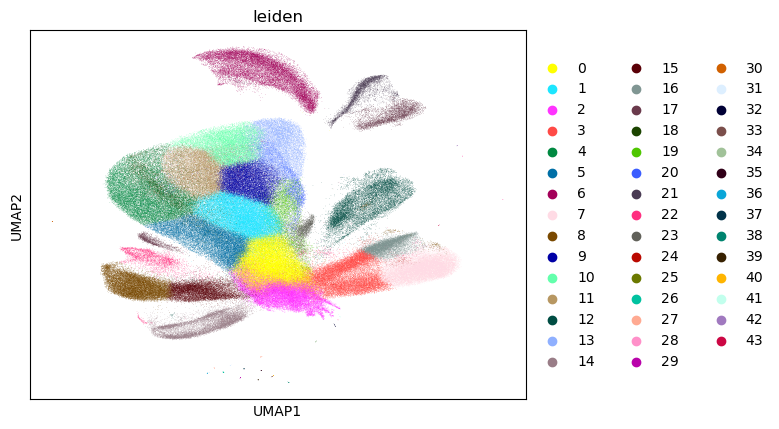

In [28]:
sc.pl.umap(adata, color=['leiden'])

In [47]:
adata22 = adata[adata.obs['leiden']=='22', :]
sc.pp.pca(adata22, mask_var='highly_variable')
sc.external.pp.harmony_integrate(adata22, key=['sample'], max_iter_harmony=20)


/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm["X_pca"] = X_pca
2024-10-29 16:09:16,771 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-10-29 16:09:17,526 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-10-29 16:09:17,584 - harmonypy - INFO - Iteration 1 of 20
2024-10-29 16:09:19,383 - harmonypy - INFO - Iteration 2 of 20
2024-10-29 16:09:21,159 - harmonypy - INFO - Iteration 3 of 20
2024-10-29 16:09:23,038 - harmonypy - INFO - Iteration 4 of 20
2024-10-29 16:09:24,657 - harmonypy - INFO - Iteration 5 of 20
2024-10-29 16:09:25,871 - harmonypy - INFO - Iteration 6 of 20
2024-10-29 16:09:27,362 - harmonypy - INFO - Iteration 7 of 20
2024-10-29 16:09:28,107 - harmonypy - INFO - Iteration 8 of 20
2024-10-29 16:09:28,922 - harmonypy - INFO - Iteration 9 of 20
2024-10-29 16:09:29,65

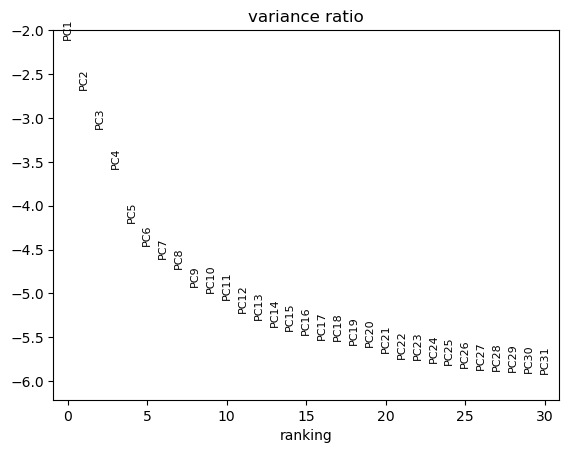

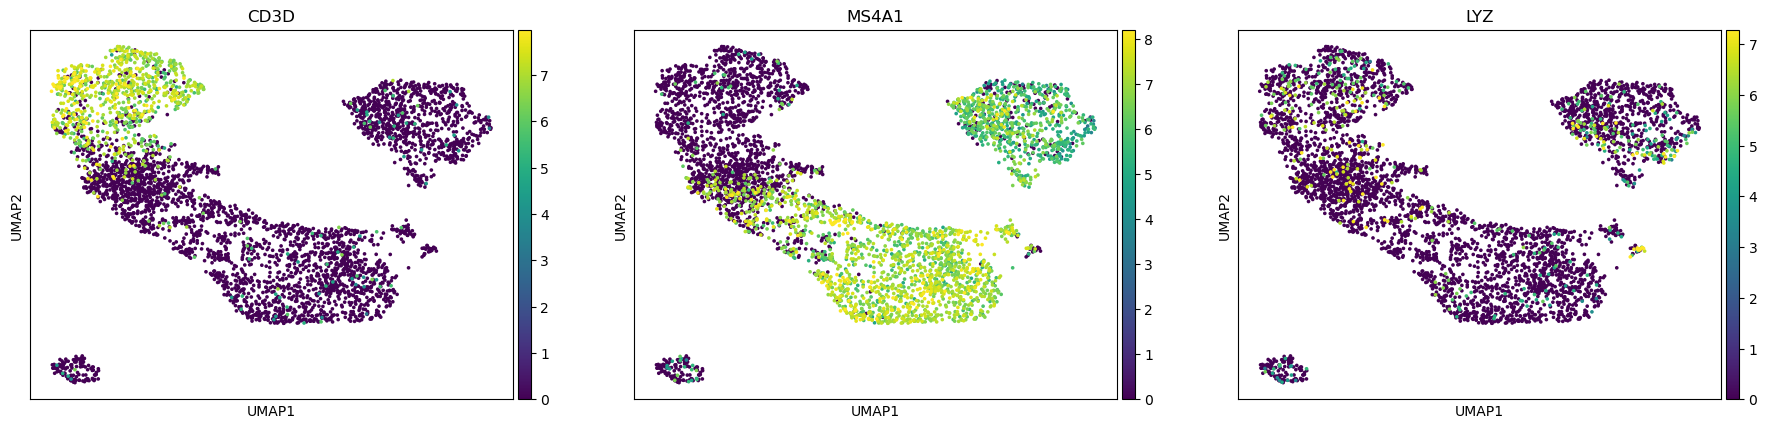

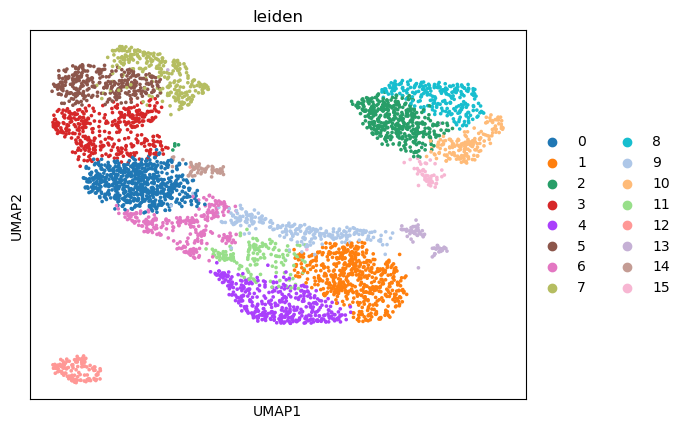

In [52]:
sc.pl.pca_variance_ratio(adata22, log=True)
sc.pp.neighbors(adata22, n_pcs=22, n_neighbors=20, use_rep='X_pca_harmony')
sc.tl.umap(adata22)
sc.pl.umap(adata22, color=['CD3D', 'MS4A1', 'LYZ'], vmax='p99')
sc.tl.leiden(adata22)
sc.pl.umap(adata22, color=['leiden'], vmax='p99')


In [60]:
t_clusters = [3, 7, 16, 24]

adata.obs['leiden_labeled'] = 'Other'
adata.obs.loc[adata.obs['leiden'].astype(int).isin(t_clusters), 'leiden_labeled'] = 'T'
ind = adata22.obs.index[adata22.obs['leiden'].isin(['3','5','7'])]
adata.obs.loc[ind, 'leiden_labeled']= 'T'

In [61]:
adata.write('../../../Data/Revision/CRC_Outcome/GSE205506_combined_logtpm.h5ad')

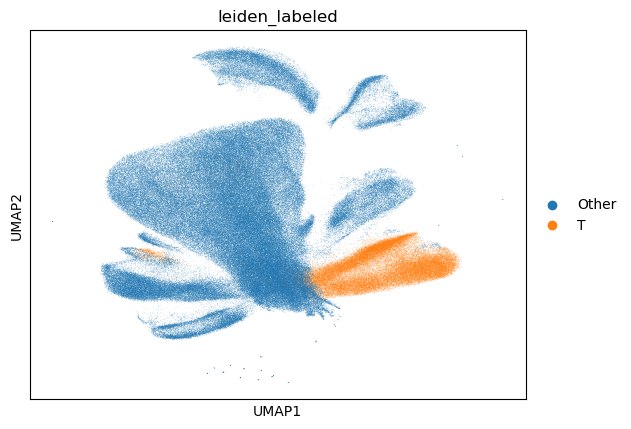

In [62]:
sc.pl.umap(adata, color=['leiden_labeled'])

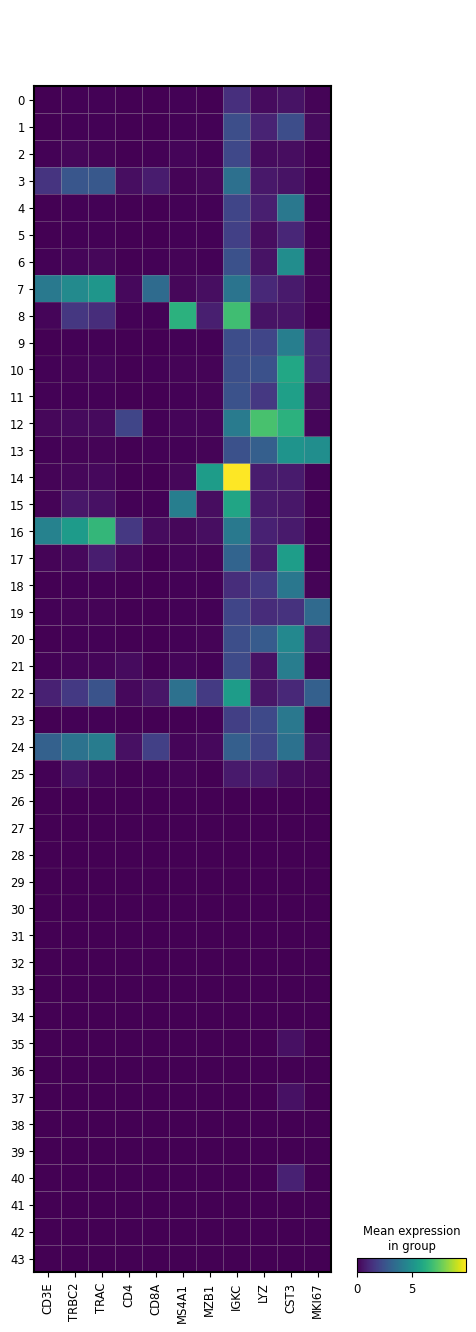

In [63]:
sc.pl.matrixplot(adata, groupby='leiden', var_names=['CD3E', 'TRBC2', 'TRAC', 'CD4', 'CD8A', 'MS4A1', 'MZB1', 'IGKC', 'LYZ', 'CST3', 'MKI67'])

In [115]:
adata = sc.read('../../../Data/Revision/CRC_Outcome/GSE205506_combined_logtpm.h5ad')

In [131]:
adata.obs['timepoint'] = adata.obs['Treatment'].replace({'untreated':'Pre', 'anti-PD-1':'Post', 'Anti-PD-1+celecoxib':'Post'})
adata.obs['response'] = adata.obs['response'].replace({'pCR':'Responder', 'non-pCR':'Non-responder'})
adata.obs['sample'] = adata.obs['Patient'].astype(str) + '_' + adata.obs['Type'].astype(str)  +  '_' + adata.obs['timepoint'].astype(str)
adata.write('../../../Data/Revision/CRC_Outcome/GSE205506_combined_logtpm.h5ad')

In [121]:
pd.crosstab([adata.obs['Patient'], adata.obs['sample']], [adata.obs['Type'], adata.obs['timepoint']])

Type                    normal  tumor       
timepoint                 Post   Post    Pre
Patient sample                              
P11     P11_normal_Post   6548      0      0
        P11_tumor_Post       0   1666      0
P12     P12_normal_Post   7755      0      0
        P12_tumor_Post       0   7509      0
P14     P14_tumor_Post       0   8118      0
P15     P15_normal_Post  16410      0      0
        P15_tumor_Post       0  15760      0
P17     P17_normal_Post   9926      0      0
        P17_tumor_Post       0   8644      0
P18     P18_normal_Post   6780      0      0
        P18_tumor_Post       0   7681      0
P19     P19_normal_Post   7043      0      0
        P19_tumor_Post       0   8742      0
P21     P21_tumor_Post       0   1357      0
        P21_tumor_Pre        0      0   7690
P23     P23_tumor_Pre        0      0  10323
P24     P24_tumor_Post       0   4826      0
        P24_tumor_Pre        0      0   7307
P25     P25_normal_Post   6789      0      0
        P25_tumor_Post       0   8126      0
        P25_tumor_Pre        0      0   9798
P26     P26_tumor_Post       0   5067      0
P27     P27_normal_Post   7546      0      0
        P27_tumor_Post       0   6744      0
        P27_tumor_Pre        0      0   7069
P28     P28_normal_Post  10942      0      0
        P28_tumor_Post       0   4109      0
        P28_tumor_Pre        0      0   6227
P29     P29_normal_Post   7260      0      0
        P29_tumor_Post       0   7355      0
P30     P30_normal_Post   8097      0      0
        P30_tumor_Post       0   5926      0
        P30_tumor_Pre        0      0  10080
P31     P31_normal_Post  11441      0      0
        P31_tumor_Post       0  11830      0
        P31_tumor_Pre        0      0   4045
P32     P32_normal_Post  11307      0      0
        P32_tumor_Post       0   9662      0
        P32_tumor_Pre        0      0  13730
P33     P33_tumor_Pre        0      0   6785

In [123]:
sample_info = adata.obs[['sample', 'Patient', 'Type', 'Treatment', 'response', 'timepoint']].drop_duplicates()
sample_info.index = sample_info['sample'].values
sample_info

,sample,Patient,Type,Treatment,response,timepoint
P11_tumor_Post,P11_tumor_Post,P11,tumor,Anti-PD-1+celecoxib,Responder,Post
P11_normal_Post,P11_normal_Post,P11,normal,Anti-PD-1+celecoxib,Responder,Post
P12_tumor_Post,P12_tumor_Post,P12,tumor,anti-PD-1,Non-responder,Post
P12_normal_Post,P12_normal_Post,P12,normal,anti-PD-1,Non-responder,Post
P14_tumor_Post,P14_tumor_Post,P14,tumor,Anti-PD-1+celecoxib,Responder,Post
P15_tumor_Post,P15_tumor_Post,P15,tumor,anti-PD-1,Responder,Post
P15_normal_Post,P15_normal_Post,P15,normal,anti-PD-1,Responder,Post
P17_tumor_Post,P17_tumor_Post,P17,tumor,anti-PD-1,Responder,Post
P17_normal_Post,P17_normal_Post,P17,normal,anti-PD-1,Responder,Post
P18_tumor_Post,P18_tumor_Post,P18,tumor,anti-PD-1,Non-responder,Post


# Analyze T-cells

In [3]:
adata_raw = sc.read('../../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.h5ad')

In [4]:
adata = sc.read('../../../Data/Revision/CRC_Outcome/GSE205506_combined_logtpm.h5ad')

In [5]:
adata = adata_raw[adata.obs['leiden_labeled']=='T', :]

In [9]:
adata.X = adata.X.astype(np.float64)

In [10]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)

In [11]:
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e6)

In [12]:
sc.pp.log1p(adata)

In [13]:
sc.pp.pca(adata, use_highly_variable=True)

/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


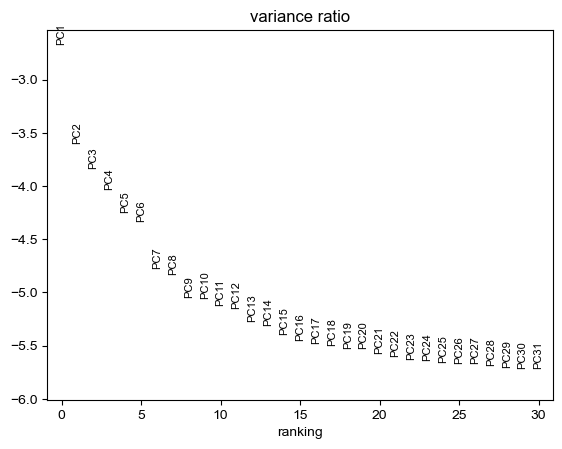

In [14]:
sc.pl.pca_variance_ratio(adata, log=True)

In [15]:
sc.external.pp.harmony_integrate(adata, key=['sample'], max_iter_harmony=30)

2024-11-01 14:29:02,871 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-11-01 14:29:07,954 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-11-01 14:29:08,370 - harmonypy - INFO - Iteration 1 of 30
2024-11-01 14:29:30,495 - harmonypy - INFO - Iteration 2 of 30
2024-11-01 14:29:54,628 - harmonypy - INFO - Iteration 3 of 30
2024-11-01 14:30:17,689 - harmonypy - INFO - Iteration 4 of 30
2024-11-01 14:30:42,659 - harmonypy - INFO - Iteration 5 of 30
2024-11-01 14:31:03,055 - harmonypy - INFO - Iteration 6 of 30
2024-11-01 14:31:17,820 - harmonypy - INFO - Iteration 7 of 30
2024-11-01 14:31:28,675 - harmonypy - INFO - Iteration 8 of 30
2024-11-01 14:31:41,575 - harmonypy - INFO - Iteration 9 of 30
2024-11-01 14:31:52,190 - harmonypy - INFO - Iteration 10 of 30
2024-11-01 14:32:02,082 - harmonypy - INFO - Iteration 11 of 30
2024-11-01 14:32:11,851 - harmonypy - INFO - Converged after 11 iterations


In [16]:
sc.pp.neighbors(adata, n_pcs=23, n_neighbors=20, use_rep='X_pca_harmony')

In [17]:
sc.tl.umap(adata)

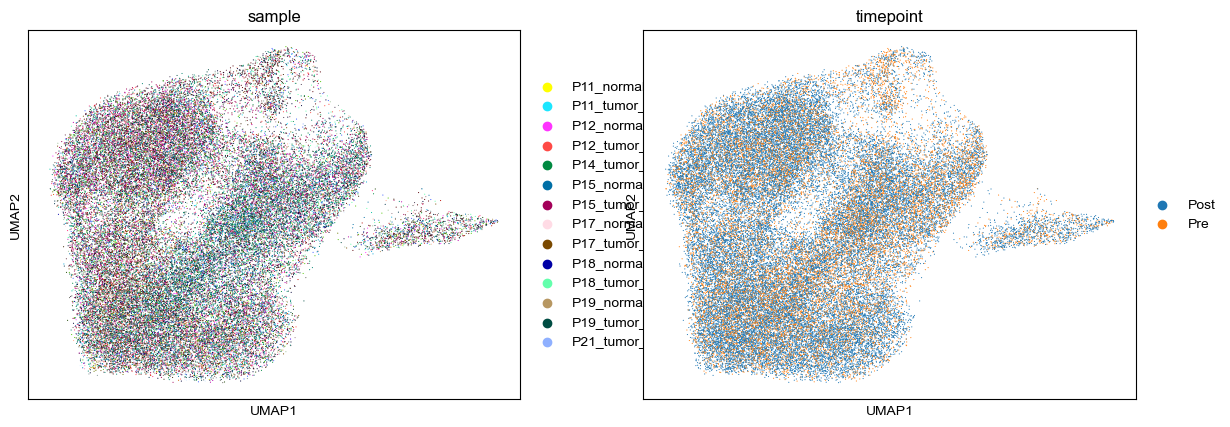

In [18]:
sc.pl.umap(adata, color=['sample', 'timepoint'])

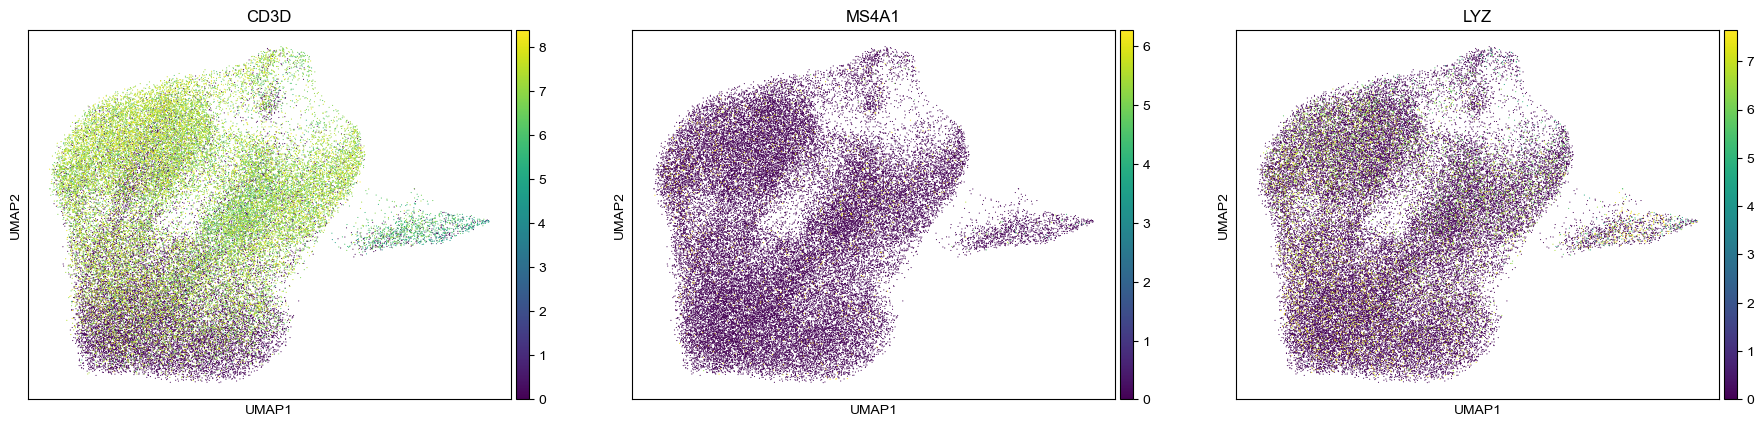

In [19]:
sc.pl.umap(adata, color=['CD3D', 'MS4A1', 'LYZ'], vmax='p99')

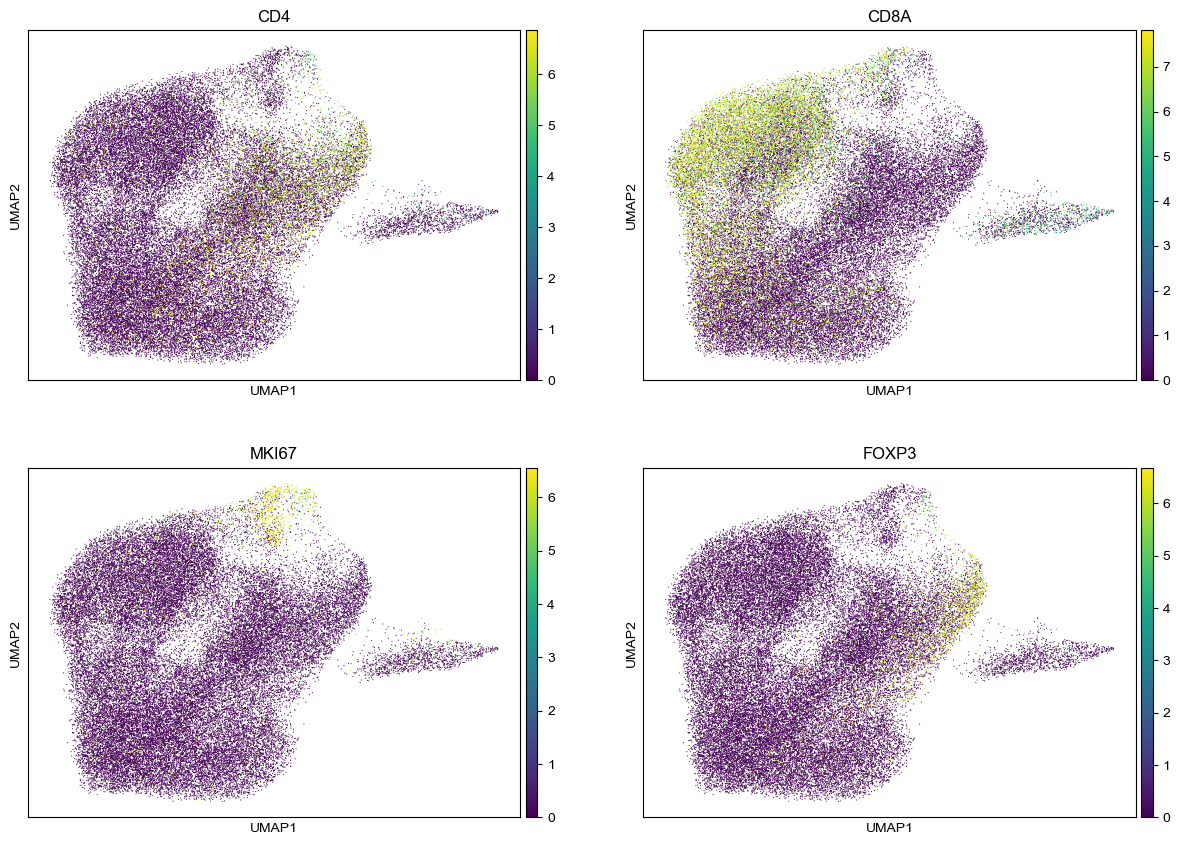

In [20]:
sc.pl.umap(adata, color=['CD4', 'CD8A', 'MKI67', 'FOXP3'], vmax='p99', ncols=2)

In [21]:
sc.tl.leiden(adata, resolution=1.0)

/tmp/ipykernel_139295/1432200975.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0)


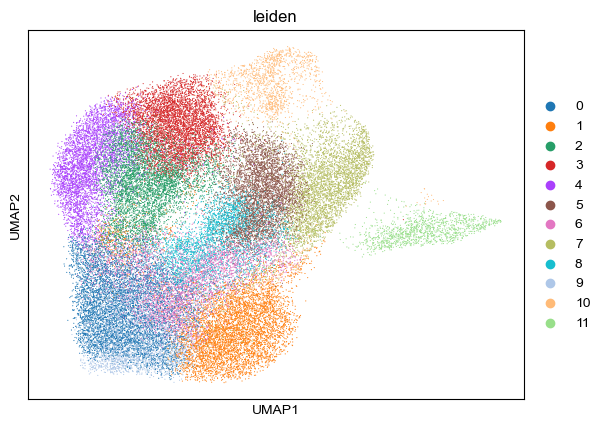

In [22]:
sc.pl.umap(adata, color=['leiden'])

In [23]:
sc.tl.rank_genes_groups(adata, groupby='leiden')

In [24]:
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(20).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,MT-CO2,MT-CO1,MT-ND4,MT-CO3,MT-CYB,MT-ATP6,MT-ND3,MT-ND1,MT-ND2,MT-ND5,AC016575.1,TTN,FNDC11,STX16-NPEPL1,TPSAB1,EFCAB12,MUC16,RBP1,AL158063.1,TGM4
1,JUN,HSPA1B,MALAT1,MT-ATP6,MT-ND4,MT-CO1,MT-CYB,MT-CO3,FOS,MT-CO2,JUNB,FOSB,MT-ND1,DNAJB1,PPP1R15A,JUND,MT-ND3,HSP90AA1,HSPA1A,DUSP1
2,CCL5,NKG7,KLRD1,TMSB4X,GZMA,ACTB,RPL10,SH3BGRL3,HOPX,RPLP1,RPL28,RPS3,B2M,RPS19,RPS27A,RPL41,RPS14,RPL13,CD63,ACTG1
3,CCL5,NKG7,RPL10,RPS3,ACTB,ACTG1,RPS14,RPS2,TMSB4X,PFN1,RPS27A,PTMA,GAPDH,HOPX,RPL28,FAU,RPLP1,RPS19,RPL21,SH3BGRL3
4,CCL5,GZMK,NKG7,GZMA,CCL4,CST7,B2M,RPL10,RPL28,HLA-C,HLA-A,CD74,RPS15A,RPS3,RPS27,TMSB4X,RPS14,RPS2,ACTB,RPL13
5,RPS3A,RPL10,RPL11,RPS14,EEF1A1,RPS4X,RPS3,RPL9,RPL13,RPL8,RPL3,RPS27A,RPS2,RPL19,RPL21,RPL32,RPL30,RPL18,RPS28,RPL28
6,TRBC1,MT-CO2,MT-CO3,MT-ND4,MT-ATP6,MT-CO1,MT-CYB,MT-ND3,MT-ND1,MT-ND2,ST8SIA1,RIC3,TSHZ2,MALAT1,TBC1D4,KSR2,CCR7,AL035563.1,IGKC,IL6R
7,GAPDH,SRGN,ACTB,HLA-A,B2M,TNFRSF4,PFN1,IL32,S100A4,TRAC,MYL6,CTLA4,ACTG1,FTH1,TNFRSF18,RPL15,H3F3A,RPS2,TMSB10,SPOCK2
8,RPLP1,RPL13,EEF1A1,RPL10,TPT1,RPL32,RPL11,RPS3A,RPS4X,RPS12,RPL19,RPL28,RPS14,RPS6,RPS3,RPS8,RPL9,RPS27A,RPL3,RPL30
9,MT-ND4L,MT-ND4,MT-CO2,MT-ATP6,MT-CYB,MT-CO1,MT-CO3,MT-ND3,MT-ND1,MT-ND2,MT-ND5,MT-ND6,MT-ATP8,TTN,AC007349.2,ADRB1,ITGA1,PPIAL4G,ATP8B4,HIST1H2BF


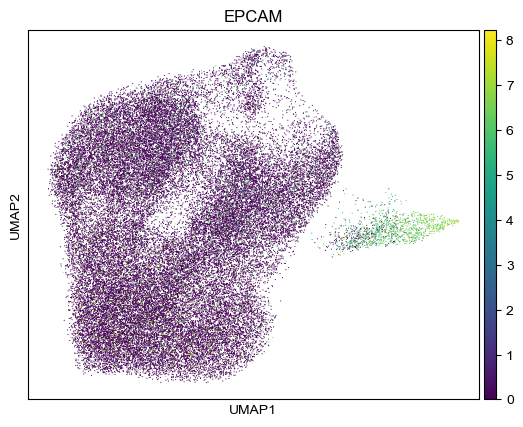

In [25]:
sc.pl.umap(adata, color=['EPCAM'])

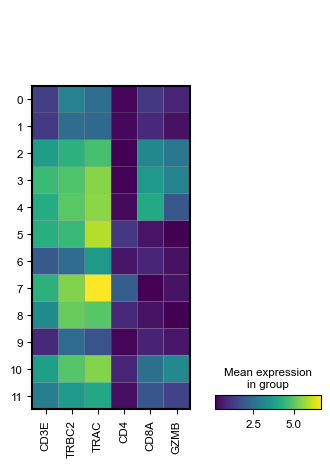

In [26]:
sc.pl.matrixplot(adata, groupby='leiden', var_names=['CD3E', 'TRBC2', 'TRAC', 'CD4', 'CD8A', 'GZMB'])

In [27]:
adata.write('../../../Data/Revision/CRC_Outcome/GSE205506_combined_logtpm.T.h5ad')

# Run TCAT

In [5]:
adata_raw = sc.read('../../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.h5ad')

In [6]:
adata = sc.read('../../../Data/Revision/CRC_Outcome/GSE205506_combined_logtpm.T.h5ad')

In [7]:
adata = adata_raw[adata.obs.index[adata.obs['leiden']!='11'], :]

In [8]:
adata.write('../../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.T.h5ad')

In [9]:
adata = sc.read('../../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.T.h5ad')

In [10]:
tcat = starCAT(reference='TCAT.V1', cachedir='../../../Data/Revision/Melanoma_Clinical_GSE120575/tcat_cache')

Using reference from starCAT database
Loading reference from existing cache file for reference TCAT.V1


In [11]:
usage, scores = tcat.fit_transform(adata)

3412 out of 3412 genes in the reference overlap with the query


/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/starcat/starcat.py:258: UserWarning: WARNING!: query input has 1 genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.
  warnings.warn("""WARNING!: query input has %d genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.""" % num_zeros, UserWarning)
/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.0.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [12]:
usage.to_csv('../../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.T.TCAT.Usage.tsv', sep='\t')
scores.to_csv('../../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.T.TCAT.Scores.tsv', sep='\t')

In [13]:
adata.obs = pd.concat([adata.obs, scores], axis=1)

In [14]:
adata.obs['TCAT_Exhaustion'] = usage['Exhaustion']
adata.obs['TCAT_Exhaustion_Bin'] = usage['Exhaustion']>0.0625

# Association

In [244]:
def run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder'):
    ttest_res = []
    for v in variables:
        T,P = ttest_ind(rdat.loc[rdat[feature]==g1lab, v], rdat.loc[rdat[feature]==g2lab, v],
                        equal_var=False)
        meandiff = rdat.loc[rdat[feature]==g1lab, v].mean() - rdat.loc[rdat[feature]==g2lab, v].mean()
        #T,P = ranksums(rdat.loc[rdat['response']=='Non-responder', v], rdat.loc[rdat['response']=='Responder', v])
        ttest_res.append([v, T, P, meandiff])

    ttest_res = pd.DataFrame(ttest_res, columns=['GEP', 'T', 'P', 'Delta'])
    ttest_res.index = ttest_res['GEP']

    _, ttest_res.loc[:, 'Q'] =  fdrcorrection(ttest_res.loc[:, 'P'])

    ttest_res['logP'] = ttest_res['P'].apply(np.log10)*-1
    ttest_res['logQ'] = ttest_res['Q'].apply(np.log10)*-1

    ttest_res['signed_logP'] = ttest_res['T'].apply(np.sign)*ttest_res['logP']
    return(ttest_res)


def run_ranksums_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder'):
    ttest_res = []
    for v in variables:
        T,P = ranksums(rdat.loc[rdat['response']=='Non-responder', v], rdat.loc[rdat['response']=='Responder', v])
        meandiff = rdat.loc[rdat[feature]==g1lab, v].mean() - rdat.loc[rdat[feature]==g2lab, v].mean()
        ttest_res.append([v, T, P, meandiff])

    ttest_res = pd.DataFrame(ttest_res, columns=['GEP', 'T', 'P', 'Delta'])
    ttest_res.index = ttest_res['GEP']

    _, ttest_res.loc[:, 'Q'] =  fdrcorrection(ttest_res.loc[:, 'P'])

    ttest_res['logP'] = ttest_res['P'].apply(np.log10)*-1
    ttest_res['logQ'] = ttest_res['Q'].apply(np.log10)*-1

    ttest_res['signed_logP'] = ttest_res['T'].apply(np.sign)*ttest_res['logP']
    return(ttest_res)


In [245]:
adata.obs['Exhaustion'] = usage['Exhaustion']
adata.obs['Multinomial_Label'] = scores['Multinomial_Label']

In [246]:
melanoma_pos = ['CellCycle-G2M', 'HLA', 'ISG', 'CellCycle-S', 'NME1/FABP5',
       'CellCycle-Late-S', 'Cytoskeleton', 'Metallothionein', 'TIMD4/TIM3',
       'ICOS/CD38', 'OX40/EBI3', 'Tph', 'Exhaustion']

melanoma_neg = ['CD4-Naive']

melanoma_un = ['Translation', 'Mito', 'Doublet-RBC', 'gdT', 'Cytotoxic',
       'Doublet-Platelet', 'Th22', 'MAIT', 'Heatshock', 'Multi-Cytokine',
       'TEMRA', 'Doublet-Myeloid', 'CD4-CM', 'IEG', 'CD8-EM', 'IEG2', 'Treg',
       'Th17-Resting', 'Poor-Quality', 'CD8-Naive', 'RGCC/MYADM',
       'Doublet-Plasmablast', 'BCL2/FAM13A', 'IL10/IL19', 'Th2-Activated',
       'Th2-Resting', 'Doublet-Bcell', 'Th1-Like', 'CTLA4/CD38', 'CD8-Trm',
       'Th17-Activated', 'Tfh-2', 'CD172a/MERTK', 'IEG3', 'Doublet-Fibroblast',
       'SOX4/TOX2', 'CD40LG/TXNIP', 'Tfh-1']

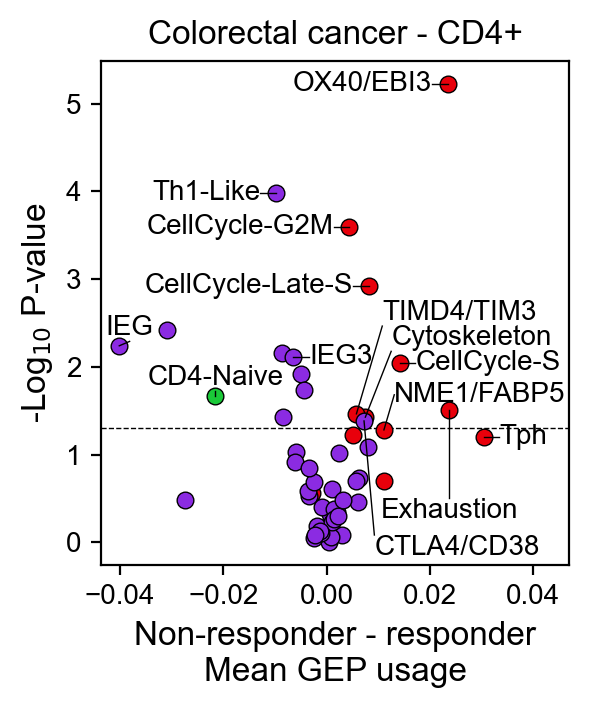

In [247]:
variables = usage.columns
ind = adata.obs['Multinomial_Label'].isin(['CD4_Naive', 'CD4_CM', 'CD4_EM']) & (adata.obs['Type']=='tumor')
allcell_usage = usage.loc[ind, :].groupby(adata.obs.loc[ind, 'sample']).mean()
allcell_act_count = adata.obs.loc[ind,:].groupby('sample').count()
sample_data_withcount = sample_info.copy()
sample_data_withcount['Count'] = allcell_act_count.loc[sample_data_withcount.index, 'file'].values
allcell_act_pct_merged = pd.merge(left=sample_data_withcount, right=allcell_usage, left_index=True, right_index=True, how='left')
allcell_act_pct_merged = allcell_act_pct_merged.loc[allcell_act_pct_merged['Count']>10, :]
r = 'Both'
if r == 'Both':
    rdat = allcell_act_pct_merged.copy()
else:
    rdat = allcell_act_pct_merged.loc[allcell_act_pct_merged['timepoint']==r, :]

ttest_res = run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder')

xval = 'Delta'
yval = 'logP'

(fig,ax) = plt.subplots(1,1, figsize=(3,4), dpi=200, gridspec_kw={'left':.2, 'right':.98, 'bottom':.23, 'top':.86})

ind1 = ttest_res.index.isin(melanoma_pos)
ind2 = ttest_res.index.isin(melanoma_neg)
ind3 = ttest_res.index.isin(melanoma_un)

ax.scatter(ttest_res.loc[ind1, 'Delta'], ttest_res.loc[ind1, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[3])
ax.scatter(ttest_res.loc[ind2, 'Delta'], ttest_res.loc[ind2, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[2])
ax.scatter(ttest_res.loc[ind3, 'Delta'], ttest_res.loc[ind3, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[4])

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.hlines(y=-1*np.log10(.05), xmin=xlim[0], xmax=xlim[1]+.5, linestyle='--', zorder=-1, color='k', lw=.5)
ax.set_xlim(xlim)

geps_to_plot = list(ttest_res.index[ttest_res['P']<.05])
geps_to_plot = ['OX40/EBI3', 'Th1-Like', 'CellCycle-G2M', 'CellCycle-Late-S',
       'IEG', 'IEG3',  'CellCycle-S', 'Cytoskeleton',
        'CD4-Naive', 'TIMD4/TIM3', 'Exhaustion', 'CTLA4/CD38', 'NME1/FABP5', 'Tph'
              ]
fs = 10
for i,g in enumerate(geps_to_plot):
    #lab = shorten_map[g]
    lab = g.replace('RGCC/MYADM', 'RGCC/MY.')


    
    if g in ['OX40/EBI3', 'CellCycle-G2M', 'CellCycle-Late-S', 'Th1-Like']: deltax = -0.003; deltay =0; ha='right'; va='center' ## Left
    elif g in ['TIMD4/TIM3',  ]: deltax = 0.005; deltay = 1; ha='left'; va='bottom' ## Upper-right
    elif g in ['Cytoskeleton', ]: deltax = 0.005; deltay = .75; ha='left'; va='bottom' ## Upper-right

    elif g in ['NME1/FABP5']: deltax = 0.002; deltay = .4; ha='left'; va='center' ## Upper-right

    elif g in ['CTLA4/CD38']: deltax = 0.002; deltay = -1.3; ha='left'; va='top' ## Lower-right
    elif g in []: deltax = -0.008; deltay =-0.4; ha='right'; va='top' ## Lower-Left
    elif g in ['CD4-Naive']: deltax = 0; deltay =0.05; ha='center'; va='bottom' ## Above
    elif g in [ 'IEG']: deltax = 0.002; deltay =0.05; ha='center'; va='bottom' ## Above

    elif g in ['Exhaustion']: deltax = -0.00; deltay =-1; ha='center'; va='top' ## Below

    elif g in []: deltax = -0.005; deltay =0.4; ha='right'; va='bottom' ## Upper-Left
    elif g in ['RGCC/MYADM']: deltax = -0.001; deltay =0.15; ha='right'; va='bottom' ## Upper-Left
    else: deltax=.003; deltay=0; ha='left'; va='center' # Default to right

    ax.text(ttest_res.at[g, xval]+deltax, ttest_res.at[g, yval]+deltay, lab, ha=ha, va=va, fontsize=fs)
    ax.plot([ttest_res.at[g, xval], ttest_res.at[g, xval]+deltax], [ttest_res.at[g, yval], ttest_res.at[g, yval]+deltay], color='k', lw=.5)
        

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.set_xlim(xlim[0], xlim[1]+.013)
ax.set_title('Colorectal cancer - CD4+', fontsize=12) 
ax.set_xlabel('Non-responder - responder\nMean GEP usage', fontsize=12)
ax.set_ylabel('-Log$_{10}$ P-value', fontsize=12)

#plt.savefig(os.path.join(figdir, 'CD4_Usage_Assoc_Volcano.png'))
#plt.savefig(os.path.join(figdir, 'CD4_Usage_Assoc_Volcano.pdf'))

plt.savefig(os.path.join(figdir, 'CD4_CRC_Combined_Usage_Assoc_Volcano.png'))
plt.savefig(os.path.join(figdir, 'CD4_CRC_Combined_Usage_Assoc_Volcano.pdf'))

ttest_res.to_csv(os.path.join(outdir, 'CD4_CRC_Combined_usage_both_gep_association.tsv'), sep='\t')

In [248]:
ttest_res.sort_values(by='P')

,GEP,T,P,Delta,Q,logP,logQ,signed_logP
GEP,,,,,,,,
OX40/EBI3,OX40/EBI3,7.867845,0.000006,0.023461,0.000307,5.228495,3.512491,5.228495
Th1-Like,Th1-Like,-4.823936,0.000104,-0.009831,0.002716,3.980987,2.566014,-3.980987
CellCycle-G2M,CellCycle-G2M,5.261604,0.000254,0.004426,0.004402,3.595203,2.356321,3.595203
CellCycle-Late-S,CellCycle-Late-S,5.287595,0.001205,0.008146,0.015667,2.918951,1.805008,2.918951
CD40LG/TXNIP,CD40LG/TXNIP,-3.208161,0.003787,-0.030970,0.039387,2.421685,1.404652,-2.421685
IEG,IEG,-3.093334,0.005757,-0.040119,0.049893,2.239810,1.301958,-2.239810
RGCC/MYADM,RGCC/MYADM,-2.939596,0.007011,-0.008613,0.049989,2.154217,1.301129,-2.154217
IEG3,IEG3,-3.043986,0.007691,-0.006403,0.049989,2.114042,1.301129,-2.114042
CellCycle-S,CellCycle-S,3.978913,0.008980,0.014201,0.051883,2.046735,1.284974,2.046735


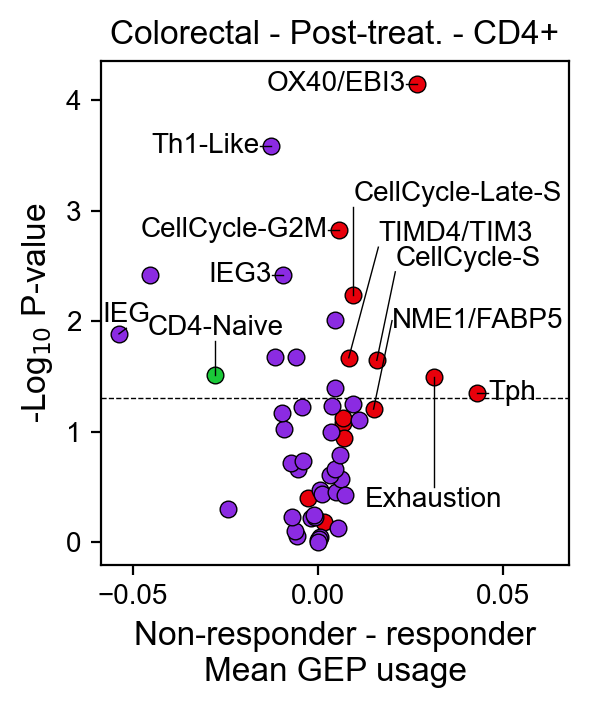

In [249]:
variables = usage.columns
ind = adata.obs['Multinomial_Label'].isin(['CD4_Naive', 'CD4_CM', 'CD4_EM']) & (adata.obs['Type']=='tumor')
allcell_usage = usage.loc[ind, :].groupby(adata.obs.loc[ind, 'sample']).mean()
allcell_act_count = adata.obs.loc[ind,:].groupby('sample').count()
sample_data_withcount = sample_info.copy()
sample_data_withcount['Count'] = allcell_act_count.loc[sample_data_withcount.index, 'file'].values
allcell_act_pct_merged = pd.merge(left=sample_data_withcount, right=allcell_usage, left_index=True, right_index=True, how='left')
allcell_act_pct_merged = allcell_act_pct_merged.loc[allcell_act_pct_merged['Count']>10, :]
r = 'Post'
if r == 'Both':
    rdat = allcell_act_pct_merged.copy()
else:
    rdat = allcell_act_pct_merged.loc[allcell_act_pct_merged['timepoint']==r, :]

ttest_res = run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder')

xval = 'Delta'
yval = 'logP'

(fig,ax) = plt.subplots(1,1, figsize=(3,4), dpi=200, gridspec_kw={'left':.2, 'right':.98, 'bottom':.23, 'top':.86})

ind1 = ttest_res.index.isin(melanoma_pos)
ind2 = ttest_res.index.isin(melanoma_neg)
ind3 = ttest_res.index.isin(melanoma_un)

ax.scatter(ttest_res.loc[ind1, 'Delta'], ttest_res.loc[ind1, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[3])
ax.scatter(ttest_res.loc[ind2, 'Delta'], ttest_res.loc[ind2, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[2])
ax.scatter(ttest_res.loc[ind3, 'Delta'], ttest_res.loc[ind3, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[4])

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.hlines(y=-1*np.log10(.05), xmin=xlim[0], xmax=xlim[1]+.5, linestyle='--', zorder=-1, color='k', lw=.5)
ax.set_xlim(xlim)

geps_to_plot = list(ttest_res.index[ttest_res['P']<.05])
geps_to_plot = ['OX40/EBI3', 'Th1-Like', 'CellCycle-G2M', 'CellCycle-Late-S',
       'IEG', 'IEG3',  'CellCycle-S', 
        'CD4-Naive', 'TIMD4/TIM3', 'Exhaustion', 'NME1/FABP5', 'Tph'
              ]
fs = 10
for i,g in enumerate(geps_to_plot):
    #lab = shorten_map[g]
    lab = g.replace('RGCC/MYADM', 'RGCC/MY.')


    
    if g in ['OX40/EBI3', 'CellCycle-G2M', 'Th1-Like', 'IEG3']: deltax = -0.003; deltay =0; ha='right'; va='center' ## Left
    elif g in ['TIMD4/TIM3',  ]: deltax = 0.008; deltay = 1; ha='left'; va='bottom' ## Upper-right
    elif g in ['CellCycle-S',  ]: deltax = 0.005; deltay = .8; ha='left'; va='bottom' ## Upper-right

    elif g in ['Cytoskeleton', ]: deltax = 0.005; deltay = .75; ha='left'; va='bottom' ## Upper-right

    elif g in ['NME1/FABP5']: deltax = 0.005; deltay = .8; ha='left'; va='center' ## Upper-right

    elif g in ['CTLA4/CD38']: deltax = 0.002; deltay = -1.3; ha='left'; va='top' ## Lower-right
    elif g in []: deltax = -0.008; deltay =-0.4; ha='right'; va='top' ## Lower-Left
    elif g in ['CD4-Naive']: deltax = 0; deltay =0.3; ha='center'; va='bottom' ## Above
    elif g in [ 'IEG']: deltax = 0.002; deltay =0.05; ha='center'; va='bottom' ## Above
    elif g in [ 'CellCycle-Late-S']: deltax = 0; deltay=.8; ha='left'; va='bottom' ## Above

    
    elif g in ['Exhaustion']: deltax = -0.00; deltay =-1; ha='center'; va='top' ## Below

    elif g in []: deltax = -0.005; deltay =0.4; ha='right'; va='bottom' ## Upper-Left
    elif g in ['RGCC/MYADM']: deltax = -0.001; deltay =0.15; ha='right'; va='bottom' ## Upper-Left
    else: deltax=.003; deltay=0; ha='left'; va='center' # Default to right

    ax.text(ttest_res.at[g, xval]+deltax, ttest_res.at[g, yval]+deltay, lab, ha=ha, va=va, fontsize=fs)
    ax.plot([ttest_res.at[g, xval], ttest_res.at[g, xval]+deltax], [ttest_res.at[g, yval], ttest_res.at[g, yval]+deltay], color='k', lw=.5)
        

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.set_xlim(xlim[0], xlim[1]+.02)
ax.set_title('Colorectal - Post-treat. - CD4+', fontsize=12) 
ax.set_xlabel('Non-responder - responder\nMean GEP usage', fontsize=12)
ax.set_ylabel('-Log$_{10}$ P-value', fontsize=12)

#plt.savefig(os.path.join(figdir, 'CD4_Usage_Assoc_Volcano.png'))
#plt.savefig(os.path.join(figdir, 'CD4_Usage_Assoc_Volcano.pdf'))

plt.savefig(os.path.join(figdir, 'CD4_CRC_Post_Usage_Assoc_Volcano.png'))
plt.savefig(os.path.join(figdir, 'CD4_CRC_Post_Usage_Assoc_Volcano.pdf'))

ttest_res.to_csv(os.path.join(outdir, 'CD4_CRC_Post_usage_gep_association.tsv'), sep='\t')
ttest_res_post = ttest_res.copy()

In [250]:
ttest_res.sort_values(by='P').head(30)

,GEP,T,P,Delta,Q,logP,logQ,signed_logP
GEP,,,,,,,,
OX40/EBI3,OX40/EBI3,9.614115,0.000071,0.026872,0.003695,4.148442,2.432439,4.148442
Th1-Like,Th1-Like,-4.971281,0.000260,-0.012758,0.006767,3.584583,2.169610,-3.584583
CellCycle-G2M,CellCycle-G2M,6.964014,0.001504,0.005649,0.026077,2.822632,1.583749,2.822632
CD40LG/TXNIP,CD40LG/TXNIP,-3.418669,0.003843,-0.045312,0.040039,2.415327,1.397516,-2.415327
IEG3,IEG3,-3.415743,0.003850,-0.009454,0.040039,2.414549,1.397516,-2.414549
CellCycle-Late-S,CellCycle-Late-S,6.325514,0.005817,0.009603,0.050416,2.235284,1.297432,2.235284
TEMRA,TEMRA,3.697348,0.009862,0.004637,0.073263,2.006021,1.135116,2.006021
IEG,IEG,-2.825130,0.013029,-0.053744,0.084686,1.885102,1.072189,-1.885102
CD8-EM,CD8-EM,-2.579608,0.020933,-0.005968,0.097950,1.679160,1.008998,-1.679160


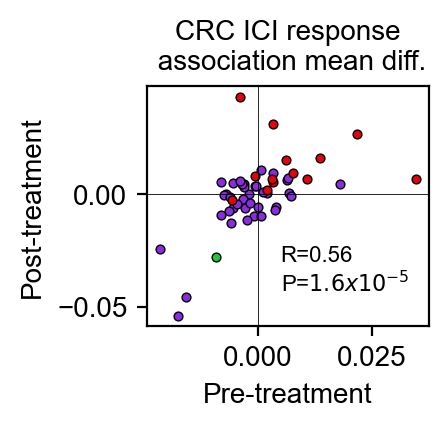

In [255]:
from scipy.stats import binom, pearsonr, fisher_exact

(fig,ax) = plt.subplots(1,1, figsize=(2.2,2), dpi=200, gridspec_kw={'left':.35, 'right':.99, 'bottom':.2, 'top':.8})

ind1 = ttest_res_post.index.isin(melanoma_pos)
ind2 = ttest_res_post.index.isin(melanoma_neg)
ind3 = ttest_res_post.index.isin(melanoma_un)
ax.scatter(ttest_res_pre.loc[ind2, 'Delta'], ttest_res_post.loc[ind2, 'Delta'], s=10, edgecolor='k', lw=.5,color=sns.color_palette("bright")[2])
ax.scatter(ttest_res_pre.loc[ind3, 'Delta'], ttest_res_post.loc[ind3, 'Delta'], s=10, edgecolor='k', lw=.5,color=sns.color_palette("bright")[4])
ax.scatter(ttest_res_pre.loc[ind1, 'Delta'], ttest_res_post.loc[ind1, 'Delta'], s=10, edgecolor='k', lw=.5,color=sns.color_palette("bright")[3])

xlim = ax.get_xlim()
ylim = ax.get_ylim()
#xlim = (-4.3, xlim[1])
ax.hlines(y=0, xmin=xlim[0], xmax=xlim[1], color='k', lw=.3)
ax.vlines(x=0, ymin=ylim[0], ymax=ylim[1], color='k', lw=.3)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Pre-treatment', fontsize=10)
ax.set_ylabel('Post-treatment', fontsize=10)
ax.set_title('CRC ICI response\n association mean diff.', fontsize=10)
R,P = pearsonr(ttest_res_pre['Delta'], ttest_res_post['Delta'])
Pstr = ('P=$%.1e' % P).replace('e-0', 'x10^{-') +'}$'
ax.text(0.005, -0.03, f'R={R:.2}', fontsize=8)
ax.text(0.005, -0.043, Pstr, fontsize=8)
plt.savefig(os.path.join(figdir, 'CD4_CRC_PreVsPost_Scatter.png'))
plt.savefig(os.path.join(figdir, 'CD4_CRC_PreVsPost_Scatter.pdf'))

In [257]:
melanoma_pos_cd8 = ['CellCycle-G2M', 'HLA', 'ISG', 'NME1/FABP5', 'CellCycle-Late-S',
       'Metallothionein', 'TIMD4/TIM3', 'ICOS/CD38', 'OX40/EBI3',
       'Exhaustion']

melanoma_neg_cd8 = ['CD4-Naive', 'Poor-Quality', 'CD8-Naive', 'Doublet-Plasmablast']

melanoma_un_cd8 = ['Translation', 'Mito', 'Doublet-RBC', 'gdT', 'CellCycle-S', 'Cytotoxic',
       'Doublet-Platelet', 'Th22', 'MAIT', 'Cytoskeleton', 'Heatshock',
       'Multi-Cytokine', 'TEMRA', 'Doublet-Myeloid', 'CD4-CM', 'IEG', 'CD8-EM',
       'IEG2', 'Treg', 'Th17-Resting', 'RGCC/MYADM', 'BCL2/FAM13A',
       'IL10/IL19', 'Th2-Activated', 'Th2-Resting', 'Doublet-Bcell',
       'Th1-Like', 'CTLA4/CD38', 'CD8-Trm', 'Th17-Activated', 'Tfh-2',
       'CD172a/MERTK', 'IEG3', 'Doublet-Fibroblast', 'SOX4/TOX2',
       'CD40LG/TXNIP', 'Tph', 'Tfh-1']

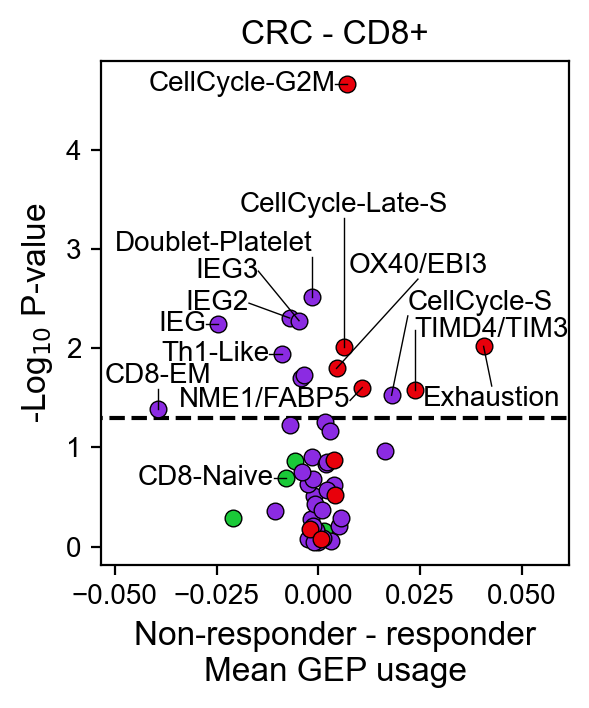

In [311]:
variables = usage.columns
ind = adata.obs['Multinomial_Label'].isin(['CD8_Naive', 'CD8_CM', 'CD8_EM', 'CD8_TEMRA']) & (adata.obs['Type']=='tumor')
allcell_usage = usage.loc[ind, :].groupby(adata.obs.loc[ind, 'sample']).mean()
allcell_act_count = adata.obs.loc[ind,:].groupby('sample').count()
sample_data_withcount = sample_info.copy()
sample_data_withcount['Count'] = allcell_act_count.loc[sample_data_withcount.index, 'file'].values
allcell_act_pct_merged = pd.merge(left=sample_data_withcount, right=allcell_usage, left_index=True, right_index=True, how='left')
allcell_act_pct_merged = allcell_act_pct_merged.loc[allcell_act_pct_merged['Count']>10, :]
r = 'Both'
if r == 'Both':
    rdat = allcell_act_pct_merged.copy()
else:
    rdat = allcell_act_pct_merged.loc[allcell_act_pct_merged['timepoint']==r, :]


ttest_res = run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder')

xval = 'Delta'
yval = 'logP'

(fig,ax) = plt.subplots(1,1, figsize=(3,4), dpi=200, gridspec_kw={'left':.2, 'right':.98, 'bottom':.23, 'top':.86})

ind1 = ttest_res.index.isin(melanoma_pos_cd8)
ind2 = ttest_res.index.isin(melanoma_neg_cd8)
ind3 = ttest_res.index.isin(melanoma_un_cd8)

ax.scatter(ttest_res.loc[ind2, 'Delta'], ttest_res.loc[ind2, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[2])
ax.scatter(ttest_res.loc[ind3, 'Delta'], ttest_res.loc[ind3, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[4])
ax.scatter(ttest_res.loc[ind1, 'Delta'], ttest_res.loc[ind1, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[3])


ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.set_xlim(xlim)

geps_to_plot = list(ttest_res.index[ttest_res['P']<.05])
geps_to_plot = ['OX40/EBI3', 'Th1-Like', 'CellCycle-G2M', 'CellCycle-Late-S',
       'IEG',  'CellCycle-S', 'TIMD4/TIM3', 'Exhaustion', 'NME1/FABP5', 'CD8-Naive', 'IEG2', 'IEG3', 'Doublet-Platelet', 'CD8-EM'
              ]
fs = 10
for i,g in enumerate(geps_to_plot):
    #lab = shorten_map[g]
    lab = g


    
    if g in ['CellCycle-G2M',  'Th1-Like', 'CD8-Naive', 'IEG']: deltax = -0.003; deltay =0; ha='right'; va='center' ## Left
    elif g in ['OX40/EBI3',]: deltax = 0.02; deltay = .9; ha='center'; va='bottom' ## Upper-right

    elif g in ['TIMD4/TIM3']: deltax = 0.00; deltay = .6; ha='left'; va='center' ## Upper-right
    elif g in [ 'CellCycle-S']: deltax = 0.004; deltay = .8; ha='left'; va='bottom' ## Upper-right

    elif g in ['CTLA4/CD38']: deltax = 0.002; deltay = -1; ha='left'; va='top' ## Lower-right
    elif g in ['NME1/FABP5']: deltax = -0.003; deltay =-0.13; ha='right'; va='center' ## Lower-Left
    elif g in ['CD8-EM']: deltax = 0; deltay =0.2; ha='center'; va='bottom' ## Above
    elif g in ['CellCycle-Late-S']: deltax = 0; deltay =1.3; ha='center'; va='bottom' ## Above

    
    
    elif g in ['Exhaustion']: deltax = 0.002; deltay =-0.4; ha='center'; va='top' ## Below
    elif g in [ 'Doublet-Platelet']: deltax = -0.0; deltay =0.4; ha='right'; va='bottom' ## Upper-Left

    elif g in ['IEG2']: deltax = -0.01; deltay =0.15; ha='right'; va='center' ## Upper-Left
    elif g in ['IEG3']: deltax = -0.01; deltay =0.5; ha='right'; va='center' ## Upper-Left

    elif g in []: deltax = -0.001; deltay =0.15; ha='right'; va='bottom' ## Upper-Left
    else: deltax=.003; deltay=0; ha='left'; va='center' # Default to right

    ax.text(ttest_res.at[g, xval]+deltax, ttest_res.at[g, yval]+deltay, lab, ha=ha, va=va, fontsize=fs)
    ax.plot([ttest_res.at[g, xval], ttest_res.at[g, xval]+deltax], [ttest_res.at[g, yval], ttest_res.at[g, yval]+deltay], color='k', lw=.5)
        

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.hlines(y=-1*np.log10(.05), xmin=xlim[0]-.1, xmax=xlim[1]+.1, linestyle='--', zorder=-1, color='k')
ax.set_xlim(xlim[0]-.01, xlim[1]+.017)
ax.set_title('CRC - CD8+', fontsize=12) 
ax.set_xlabel('Non-responder - responder\nMean GEP usage', fontsize=12)
ax.set_ylabel('-Log$_{10}$ P-value', fontsize=12)

ttest_res_CD8 = ttest_res


plt.savefig(os.path.join(figdir, 'CD8_CRC_Combined_Usage_Assoc_Volcano.png'))
plt.savefig(os.path.join(figdir, 'CD8_CRC_Combined_Usage_Assoc_Volcano.pdf'))

ttest_res.to_csv(os.path.join(outdir, 'CD8_CRC_Combined_usage_both_gep_association.tsv'), sep='\t')

In [295]:
ttest_res.sort_values(by='P')

,GEP,T,P,Delta,Q,logP,logQ,signed_logP
GEP,,,,,,,,
CellCycle-G2M,CellCycle-G2M,6.638143,0.000021,0.007165,0.001115,4.668818,2.952815,4.668818
Doublet-Platelet,Doublet-Platelet,-3.282239,0.003037,-0.001472,0.059632,2.517526,1.224517,-2.517526
IEG2,IEG2,-3.133281,0.004956,-0.007022,0.059632,2.304855,1.224517,-2.304855
IEG3,IEG3,-3.558977,0.005272,-0.004732,0.059632,2.278011,1.224517,-2.278011
IEG,IEG,-3.272110,0.005734,-0.024629,0.059632,2.241551,1.224517,-2.241551
Exhaustion,Exhaustion,4.168644,0.009566,0.040623,0.072395,2.019280,1.140291,2.019280
CellCycle-Late-S,CellCycle-Late-S,3.206203,0.009745,0.006200,0.072395,2.011197,1.140291,2.011197
Th1-Like,Th1-Like,-3.117759,0.011377,-0.009032,0.073947,1.943991,1.131078,-1.943991
OX40/EBI3,OX40/EBI3,3.236947,0.015950,0.004488,0.092157,1.797232,1.035471,1.797232


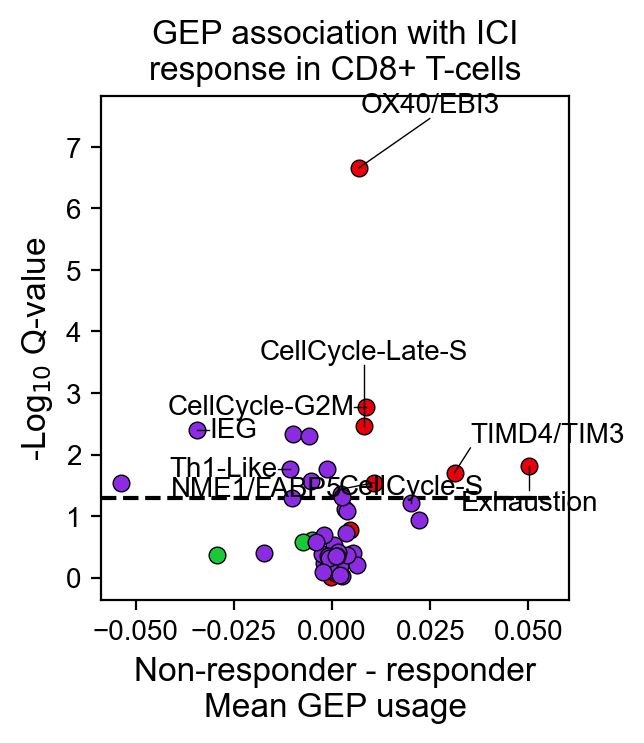

In [193]:
variables = usage.columns
ind = adata.obs['Multinomial_Label'].isin(['CD8_Naive', 'CD8_CM', 'CD8_EM', 'CD8_TEMRA']) & (adata.obs['Type']=='tumor')
allcell_usage = usage.loc[ind, :].groupby(adata.obs.loc[ind, 'sample']).mean()
allcell_act_count = adata.obs.loc[ind,:].groupby('sample').count()
sample_data_withcount = sample_info.copy()
sample_data_withcount['Count'] = allcell_act_count.loc[sample_data_withcount.index, 'file'].values
allcell_act_pct_merged = pd.merge(left=sample_data_withcount, right=allcell_usage, left_index=True, right_index=True, how='left')
allcell_act_pct_merged = allcell_act_pct_merged.loc[allcell_act_pct_merged['Count']>10, :]
r = 'Post'
if r == 'Both':
    rdat = allcell_act_pct_merged.copy()
else:
    rdat = allcell_act_pct_merged.loc[allcell_act_pct_merged['timepoint']==r, :]

ttest_res = run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder')

xval = 'Delta'
yval = 'logP'

(fig,ax) = plt.subplots(1,1, figsize=(3,4), dpi=200, gridspec_kw={'left':.2, 'right':.98, 'bottom':.23, 'top':.86})

ind1 = ttest_res.index.isin(melanoma_pos_cd8)
ind2 = ttest_res.index.isin(melanoma_neg_cd8)
ind3 = ttest_res.index.isin(melanoma_un_cd8)

ax.scatter(ttest_res.loc[ind1, 'Delta'], ttest_res.loc[ind1, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[3])
ax.scatter(ttest_res.loc[ind2, 'Delta'], ttest_res.loc[ind2, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[2])
ax.scatter(ttest_res.loc[ind3, 'Delta'], ttest_res.loc[ind3, 'logP'], edgecolor='k', lw=.5, color=sns.color_palette("bright")[4])

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.hlines(y=-1*np.log10(.05), xmin=xlim[0], xmax=xlim[1], linestyle='--', zorder=-1, color='k')
ax.set_xlim(xlim)

geps_to_plot = list(ttest_res.index[ttest_res['P']<.05])
geps_to_plot = ['OX40/EBI3', 'Th1-Like', 'CellCycle-G2M', 'CellCycle-Late-S',
       'IEG',  'CellCycle-S', 'TIMD4/TIM3', 'Exhaustion', 'NME1/FABP5'
              ]
fs = 10
for i,g in enumerate(geps_to_plot):
    #lab = shorten_map[g]
    lab = g


    
    if g in ['CellCycle-G2M',  'Th1-Like', ]: deltax = -0.003; deltay =0; ha='right'; va='center' ## Left
    elif g in ['OX40/EBI3',]: deltax = 0.018; deltay = .8; ha='center'; va='bottom' ## Upper-right

    elif g in ['TIMD4/TIM3']: deltax = 0.004; deltay = .4; ha='left'; va='bottom' ## Upper-right
    elif g in ['CTLA4/CD38']: deltax = 0.002; deltay = -1; ha='left'; va='top' ## Lower-right
    elif g in ['NME1/FABP5']: deltax = -0.008; deltay =-0.1; ha='right'; va='center' ## Lower-Left
    elif g in ['CellCycle-S']: deltax = 0; deltay =0.05; ha='center'; va='bottom' ## Above
    elif g in ['CellCycle-Late-S',]: deltax = 0; deltay =1; ha='center'; va='bottom' ## Above

    
    
    elif g in ['Exhaustion']: deltax = 0.00; deltay =-0.4; ha='center'; va='top' ## Below

    elif g in []: deltax = -0.005; deltay =0.4; ha='right'; va='bottom' ## Upper-Left
    elif g in []: deltax = -0.001; deltay =0.15; ha='right'; va='bottom' ## Upper-Left
    else: deltax=.003; deltay=0; ha='left'; va='center' # Default to right

    ax.text(ttest_res.at[g, xval]+deltax, ttest_res.at[g, yval]+deltay, lab, ha=ha, va=va, fontsize=fs)
    ax.plot([ttest_res.at[g, xval], ttest_res.at[g, xval]+deltax], [ttest_res.at[g, yval], ttest_res.at[g, yval]+deltay], color='k', lw=.5)
        

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.hlines(y=-1*np.log10(.05), xmin=xlim[0]+.1, xmax=xlim[1], linestyle='--', zorder=-1, color='k')
ax.set_xlim(xlim[0], xlim[1]+.005)
ax.set_title('GEP association with ICI\nresponse in CD8+ T-cells', fontsize=12) 
ax.set_xlabel('Non-responder - responder\nMean GEP usage', fontsize=12)
ax.set_ylabel('-Log$_{10}$ Q-value', fontsize=12)

ttest_res_CD8 = ttest_res


plt.savefig(os.path.join(figdir, 'CD8_CRC_Post_Usage_Assoc_Volcano.png'))
plt.savefig(os.path.join(figdir, 'CD8_CRC_Post_Usage_Assoc_Volcano.pdf'))

ttest_res.to_csv(os.path.join(outdir, 'CD8_CRC_usage_post_gep_association.tsv'), sep='\t')

In [196]:
ttest_res.sort_values(by='P').head(30)

,GEP,T,P,Delta,Q,logP,logQ,signed_logP
GEP,,,,,,,,
OX40/EBI3,OX40/EBI3,11.750194,2.189434e-07,0.006892,0.000011,6.659668,4.943665,6.659668
CellCycle-G2M,CellCycle-G2M,8.270682,1.694492e-03,0.008647,0.043764,2.770960,1.358886,2.770960
CellCycle-Late-S,CellCycle-Late-S,3.518553,3.500158e-03,0.008058,0.043764,2.455912,1.358886,2.455912
IEG,IEG,-3.475159,4.045353e-03,-0.034318,0.043764,2.393044,1.358886,-2.393044
IEG2,IEG2,-3.359694,4.578963e-03,-0.009882,0.043764,2.339233,1.358886,-2.339233
IEG3,IEG3,-3.449781,5.049654e-03,-0.005815,0.043764,2.296738,1.358886,-2.296738
Exhaustion,Exhaustion,4.636571,1.521653e-02,0.050157,0.101217,1.817684,0.994745,1.817684
Doublet-Platelet,Doublet-Platelet,-2.689772,1.716074e-02,-0.001288,0.101217,1.765464,0.994745,-1.765464
Th1-Like,Th1-Like,-3.157583,1.751840e-02,-0.010807,0.101217,1.756506,0.994745,-1.756506


In [198]:
adata.obs['CD4-Naive'] = usage['CD4-Naive']

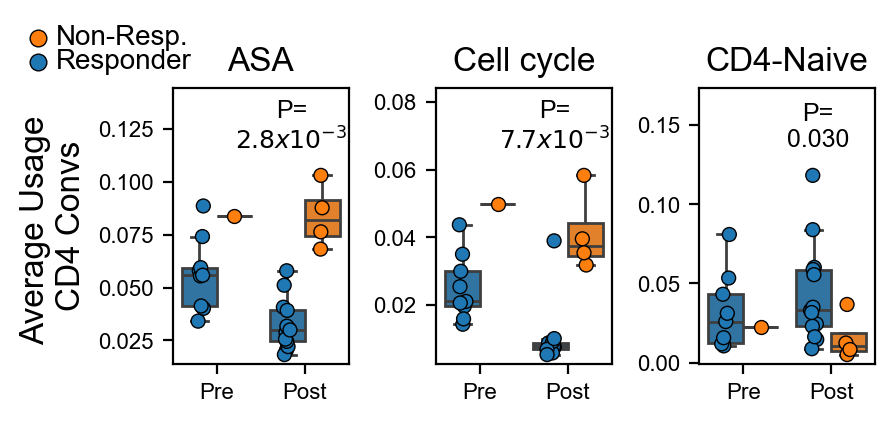

In [242]:
variables = ['ASA', 'Proliferation', 'CD4-Naive']
labels = ['ASA', 'Cell cycle', 'CD4-Naive']
ind = adata.obs['Multinomial_Label'].isin(['CD4_Naive', 'CD4_CM', 'CD4_EM']) & (adata.obs['Type']=='tumor')

allcell_score_pct = adata.obs.loc[ind, :].groupby('sample')[variables].mean()
allcell_score_count = adata.obs.loc[ind, :].groupby('sample').count()
allcell_score_pct['Count'] = allcell_score_count['file'].values
allcell_score_pct = allcell_score_pct.loc[allcell_score_pct['Count']>10, :]
allcell_score_pct_merged = pd.merge(left=sample_info, right=allcell_score_pct, left_index=True, right_index=True, how='right')

ind = allcell_score_pct_merged['timepoint']=='Post'
rdat = allcell_score_pct_merged.loc[ind, :]
ttest_res = run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder')

(fig,axes) = plt.subplots(1,3, figsize=(4.5,2), dpi=200, gridspec_kw={'top':.8, 'left':.2, 'right':.98, 'wspace':.5})

for i, val in enumerate(variables):
    sns.stripplot(x='timepoint', y=val, hue='response', data=allcell_score_pct_merged, ax=axes[i], dodge=True, legend=False,
             order=['Pre', 'Post'], hue_order=['Responder', 'Non-responder'], edgecolor='0', linewidth=.5)
        
    sns.boxplot(x='timepoint', y=val, hue='response', data=allcell_score_pct_merged, ax=axes[i], dodge=True, legend=False,
             order=['Pre', 'Post'], hue_order=['Responder', 'Non-responder'], fliersize=0)
    axes[i].set_title(labels[i])
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    ylim = axes[i].get_ylim()
    axes[i].set_ylim([ylim[0], ylim[0]+(ylim[1]-ylim[0])*1.4])
    yval = ylim[0]+(ylim[1]-ylim[0])*1.2

    P2 = ttest_res.loc[val, 'P']
    if P2 < 0.01:
        Pstr = ('P=\n$%.1e' % P2).replace('e-0', 'x10^{-') +'}$'
    else:
        Pstr = 'P=\n%.3f' % np.round(P2, 3)
    axes[i].text(.85, yval, Pstr, ha='center', va='center', fontsize=9)
    axes[i].tick_params(labelsize=8)
'''
axes[0].set_yticks([0, 25.0, 50.0, 75.0])
axes[0].set_yticklabels(['0.0', '25.0', '50.0', '75.0'])
axes[1].set_yticks([0, 25.0, 50.0, 75.0])
axes[1].set_yticklabels(['0.0', '25.0', '50.0', '75.0'])
'''
axes[0].set_ylabel('Average Usage \nCD4 Convs', fontsize=12)

legend_ax = fig.add_axes([0.03, 0.82, 0.2, 0.15], frameon=False)
legend_ax.scatter([.1], [.3], color='tab:blue', edgecolor='0', linewidth=.5)
legend_ax.scatter([.1], [.7], color='tab:orange', edgecolor='0', linewidth=.5)
legend_ax.text(.2, .7, 'Non-Resp.', ha='left', va='center', fontsize=10)
legend_ax.text(.2, .3, 'Responder', ha='left', va='center', fontsize=10)
legend_ax.set_xlim([0, 1])
legend_ax.set_ylim([0, 1])
legend_ax.set_xticks([])
legend_ax.set_yticks([])

plt.savefig(os.path.join(figdir, 'CRC_PrePost_CD4_Score_assoc_boxplot.png'))
plt.savefig(os.path.join(figdir, 'CRC_PrePost_CD4_Score_assoc_boxplot.pdf'))

In [222]:
ttest_res = run_ttest_all(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder')

ttest_res

,GEP,T,P,Delta,Q,logP,logQ,signed_logP
GEP,,,,,,,,
ASA,ASA,6.240767,0.002820,0.051399,0.008459,2.549777,2.072656,2.549777
Proliferation,Proliferation,4.887360,0.007726,0.031188,0.011590,2.112023,1.935932,2.112023
CD4-Naive,CD4-Naive,-2.457620,0.030428,-0.027695,0.030428,1.516724,1.516724,-1.516724


In [217]:
ttest_res

,,timepoint,response,T,P


P=8.6e-01 P=3.2e-03
(0.02084251011024859, 0.10304696153374676)
P=1.2e-01 P=9.2e-03
(0.0014856072397864818, 0.08288148565046079)
P=3.8e-01 P=3.2e-03
(0.00382986543700099, 0.09626813167706132)


[]

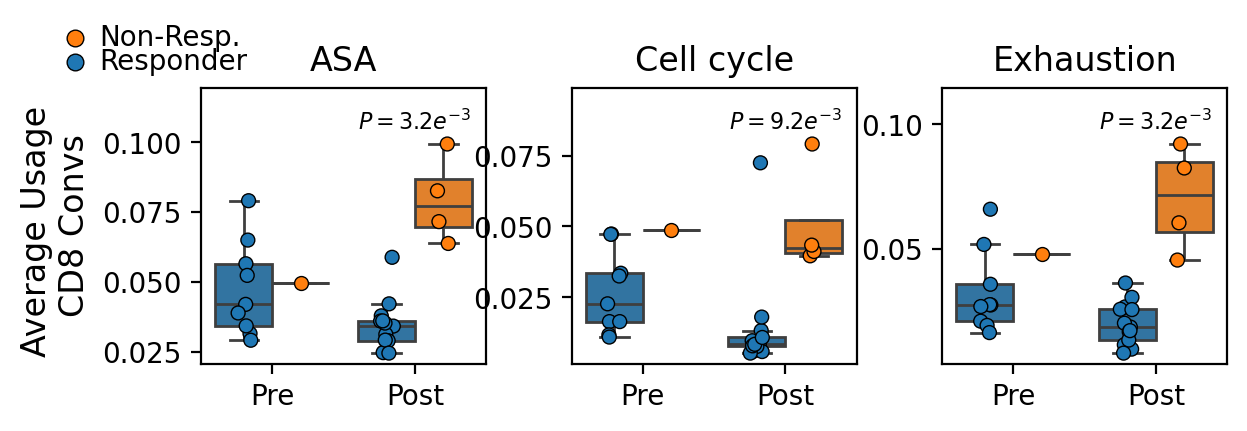

In [373]:
variables = ['ASA', 'Proliferation', 'Exhaustion']
labels = ['ASA', 'Cell cycle', 'Exhaustion']
ind = adata.obs['Multinomial_Label'].isin(['CD8_Naive', 'CD8_CM', 'CD8_EM', 'CD8_TEMRA']) & (adata.obs['Type']=='tumor')

allcell_score_pct = adata.obs.loc[ind, :].groupby('sample')[variables].mean()
allcell_score_count = adata.obs.loc[ind, :].groupby('sample').count()
allcell_score_pct['Count'] = allcell_score_count['file'].values
allcell_score_pct = allcell_score_pct.loc[allcell_score_pct['Count']>10, :]
allcell_score_pct_merged = pd.merge(left=sample_info, right=allcell_score_pct, left_index=True, right_index=True, how='right')

ttest_res = []
for r, rdat in allcell_score_pct_merged.groupby('timepoint'):
    for v in variables:
        #T,P = ttest_ind(rdat.loc[rdat['response']=='Non-responder', v], rdat.loc[rdat['response']=='Responder', v],
        #                equal_var=False)
        T,P = ranksums(rdat.loc[rdat['response']=='Non-responder', v], rdat.loc[rdat['response']=='Responder', v])
        ttest_res.append([r, v, T, P])

ttest_res = pd.DataFrame(ttest_res, columns=['timepoint', 'response', 'T', 'P'])
ttest_res.index = pd.MultiIndex.from_arrays([ttest_res['timepoint'].tolist(), ttest_res['response'].tolist()])

(fig,axes) = plt.subplots(1,3, figsize=(6,2), dpi=200, gridspec_kw={'top':.8, 'right':.98, 'wspace':.3})

for i, val in enumerate(variables):
    sns.stripplot(x='timepoint', y=val, hue='response', data=allcell_score_pct_merged, ax=axes[i], dodge=True, legend=False,
             order=['Pre', 'Post'], hue_order=['Responder', 'Non-responder'], edgecolor='0', linewidth=.5)
        
    sns.boxplot(x='timepoint', y=val, hue='response', data=allcell_score_pct_merged, ax=axes[i], dodge=True, legend=False,
             order=['Pre', 'Post'], hue_order=['Responder', 'Non-responder'], fliersize=0)
    axes[i].set_title(labels[i])
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    ylim = axes[i].get_ylim()
    axes[i].set_ylim([ylim[0], ylim[0]+(ylim[1]-ylim[0])*1.2])
    yval = ylim[0]+(ylim[1]-ylim[0])*1.05
    P1 =  'P=%.1e' % ttest_res.loc[('Pre', val), 'P']
    P2 = 'P=%.1e' % ttest_res.loc[('Post', val), 'P']
    print(P1, P2)
    P1 = '$' + P1.replace('e-0', 'e^{-') + '}$'
    P2 = '$' + P2.replace('e-0', 'e^{-') + '}$'
    #axes[i].text(0, yval, P1, ha='center', va='center', fontsize=8)
    if 'nan' not in P2:
        axes[i].text(1, yval, P2, ha='center', va='center', fontsize=8)

    print(ylim)

'''
axes[0].set_yticks([0, 25.0, 50.0, 75.0])
axes[0].set_yticklabels(['0.0', '25.0', '50.0', '75.0'])
axes[1].set_yticks([0, 25.0, 50.0, 75.0])
axes[1].set_yticklabels(['0.0', '25.0', '50.0', '75.0'])
'''
axes[0].set_ylabel('Average Usage \nCD8 Convs', fontsize=12)

legend_ax = fig.add_axes([0, 0.82, 0.2, 0.15], frameon=False)
legend_ax.scatter([.1], [.3], color='tab:blue', edgecolor='0', linewidth=.5)
legend_ax.scatter([.1], [.7], color='tab:orange', edgecolor='0', linewidth=.5)
legend_ax.text(.2, .7, 'Non-Resp.', ha='left', va='center', fontsize=10)
legend_ax.text(.2, .3, 'Responder', ha='left', va='center', fontsize=10)
legend_ax.set_xlim([0, 1])
legend_ax.set_ylim([0, 1])
legend_ax.set_xticks([])
legend_ax.set_yticks([])

#plt.savefig(os.path.join(figdir, 'CD4_Score_assoc_boxplot.png'))

In [360]:
rdat

,sample,Patient,Type,Treatment,response,timepoint,ASA,Proliferation,Exhaustion,Count
sample,,,,,,,,,,
P11_tumor_Post,P11_tumor_Post,P11,tumor,Anti-PD-1+celecoxib,Responder,Post,0.040719,0.007507,0.005737,128
P12_tumor_Post,P12_tumor_Post,P12,tumor,anti-PD-1,Non-responder,Post,0.068176,0.039528,0.026786,445
P14_tumor_Post,P14_tumor_Post,P14,tumor,Anti-PD-1+celecoxib,Responder,Post,0.057938,0.008426,0.011958,1057
P15_tumor_Post,P15_tumor_Post,P15,tumor,anti-PD-1,Responder,Post,0.051115,0.006679,0.017516,2587
P17_tumor_Post,P17_tumor_Post,P17,tumor,anti-PD-1,Responder,Post,0.020506,0.007953,0.005255,558
P18_tumor_Post,P18_tumor_Post,P18,tumor,anti-PD-1,Non-responder,Post,0.087692,0.031779,0.031716,651
P19_tumor_Post,P19_tumor_Post,P19,tumor,Anti-PD-1+celecoxib,Responder,Post,0.018340,0.008761,0.013065,548
P21_tumor_Post,P21_tumor_Post,P21,tumor,Anti-PD-1+celecoxib,Responder,Post,0.022115,0.038931,0.010657,32
P24_tumor_Post,P24_tumor_Post,P24,tumor,Anti-PD-1+celecoxib,Responder,Post,0.039221,0.007912,0.009363,364
